# C04 – Validation, Outliers, Scaling & Metrics (M4) – Classification
**IT3051 Fundamentals of Data Mining – Mini Project 2026**
**Task:** Classification – predict **`Late_delivery_risk`** at order placement.
**Owner:** M4 (Numeric prep & Evaluation)

### What this notebook does
1. Defines the team's **validation design** and **scores**, and proves the validation is fair.
2. Checks **outliers and skew** in the model's numeric features.
3. Chooses the **scaling** for each type of model (linear, distance-based, tree) with cross-validation.
4. Scores the baselines and the team's features with all metrics – the reference for the model notebooks.

| Input | Output |
|---|---|
| `train_clf_fe.csv`, `test_clf_fe.csv` (C02), `results/clf_m3_selection.json` (C03) | `results/clf_m4_preprocessing.json`, rows in `results/clf_experiments.csv`, charts in `reports/figures/clf_m4/` |

**Runtime:** KNN experiments use 30% of the orders to stay fast. Allow several minutes for Step 4.

## Step 0 – Setup

The team's shared helpers for classification:
- `classification_metrics` – the 5 scores. **ROC-AUC** is the main score (how well late orders are separated from on-time ones);
  **recall** is the business priority (how many late orders are caught).
- `make_cv` – the 5 fair folds: orders stay together, same % of late orders in every fold.
- `cv_evaluate` – trains a fresh copy of the model on each fold, scores it, returns the averages and `roc_auc_std` (fold-to-fold noise).
- `log_experiment` – adds a result line to the shared `results/clf_experiments.csv`.
- `build_preprocessor` / `build_full_pipeline` – rebuild C03's encoding, add C04's scaler if needed, then the model – all in one pipeline.


| Score | Simple meaning |
| --- | --- |
| **ROC-AUC** (main) | how well the model ranks late orders above on-time ones (0.5 = random, 1 = perfect) |
| Accuracy | % of orders guessed correctly |
| Precision | of orders called "late", % really late |
| **Recall** (business priority) | of really-late orders, % caught |
| F1 | balance of precision and recall |

In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import loguniform

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results"
FIG_DIR = ROOT / "reports" / "figures" / "clf_m4"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TARGET, GROUP, SEED = "Late_delivery_risk", "Order Id", 42
METRICS = ["roc_auc", "accuracy", "precision", "recall", "f1"]
SCALERS = {"none": None, "standard": StandardScaler, "robust": RobustScaler, "minmax": MinMaxScaler}

def show(fig, name):
    fig.tight_layout(); fig.savefig(FIG_DIR / f"{name}.png", dpi=120); plt.show()

def classification_metrics(y_true, y_pred, y_proba):
    return {"roc_auc": roc_auc_score(y_true, y_proba),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)}

def make_cv(X, y, groups, n_splits=5, seed=SEED):
    return list(StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed).split(X, y, groups))

def cv_evaluate(pipe, X, y, cv_splits, return_proba=False):
    rows, oof = [], np.full(len(y), np.nan)
    for i, (tr, va) in enumerate(cv_splits):
        model = clone(pipe).fit(X.iloc[tr], y.iloc[tr])
        proba = model.predict_proba(X.iloc[va])[:, 1]
        oof[va] = proba
        rows.append({"fold": i, **classification_metrics(y.iloc[va], (proba >= 0.5).astype(int), proba)})
    per_fold = pd.DataFrame(rows)
    summary = {m: float(per_fold[m].mean()) for m in METRICS}
    summary["roc_auc_std"] = float(per_fold["roc_auc"].std())
    return (summary, per_fold, oof) if return_proba else (summary, per_fold)

def log_experiment(row, path=RESULTS_DIR / "clf_experiments.csv"):
    new = pd.DataFrame([row])
    out = pd.concat([pd.read_csv(path), new], ignore_index=True) if path.exists() else new
    out.to_csv(path, index=False)

def build_preprocessor(plan):
    parts = []
    if plan["numeric"]:
        parts.append(("num", SimpleImputer(strategy="median"), plan["numeric"]))
    if plan["onehot"]:
        parts.append(("onehot", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                                          ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), plan["onehot"]))
    if plan["onehot_rare"]:
        parts.append(("onehot_rare", OneHotEncoder(min_frequency=0.01, handle_unknown="infrequent_if_exist",
                                                   sparse_output=False), plan["onehot_rare"]))
    if plan["target"]:
        parts.append(("target", TargetEncoder(target_type="binary", random_state=SEED), plan["target"]))
    return ColumnTransformer(parts, remainder="drop")

def build_full_pipeline(model, plan, scaler="none"):
    steps = [("prep", build_preprocessor(plan))]
    if SCALERS[scaler] is not None:
        steps.append(("scale", SCALERS[scaler]()))
    steps.append(("model", model))
    return Pipeline(steps)

from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
KNN_ORDER_FRAC = 0.3

## Step 1 – Load the data, C03's plan and the folds

In [4]:
m3 = json.loads((RESULTS_DIR / "clf_m3_selection.json").read_text(encoding="utf-8"))
FEATURES, PLAN, CATEGORY_COL = m3["features"], m3["plan"], m3["category_column"]
train = pd.read_csv(PROCESSED_DIR / "train_clf_fe.csv")
if CATEGORY_COL == "Category Id":
    train[CATEGORY_COL] = train[CATEGORY_COL].astype(str)
X, y, groups = train.drop(columns=[TARGET]), train[TARGET], train[GROUP]
cv_splits = make_cv(X, y, groups)

print(f"Train: {len(X):,} rows, {groups.nunique():,} orders, late {y.mean() * 100:.1f}%")
print("Features:", FEATURES)
print("Encoding plan:", {k: v for k, v in PLAN.items() if v})

Train: 138,231 rows, 50,318 orders, late 57.2%
Features: ['Shipping Mode', 'Market', 'Order Country', 'Category Name', 'Order Item Quantity', 'Customer Segment', 'order_weekday', 'order_month', 'order_hour', 'order_quarter', 'is_weekend']
Encoding plan: {'numeric': ['Order Item Quantity', 'order_weekday', 'order_month', 'order_hour', 'order_quarter', 'is_weekend'], 'onehot': ['Shipping Mode', 'Market', 'Customer Segment'], 'target': ['Order Country', 'Category Name'], 'high_card_strategy': 'target'}


## Step 2 – Validation design
### 2.1 Check every fold
**Grouped:** `orders_in_both` must be 0. **Stratified:** every fold should have almost the same % of late orders as the whole training set.

In [5]:
folds = pd.DataFrame([{"fold": i, "train_rows": len(tr), "val_rows": len(va), "val_orders": groups.iloc[va].nunique(),
                       "val_late_%": y.iloc[va].mean() * 100,
                       "orders_in_both": len(set(groups.iloc[tr]) & set(groups.iloc[va]))}
                      for i, (tr, va) in enumerate(cv_splits)])
print(f"Whole training set: {y.mean() * 100:.2f}% late")
folds.round(2)

Whole training set: 57.18% late


,fold,train_rows,val_rows,val_orders,val_late_%,orders_in_both
0,0,110791,27440,10063,57.65,0
1,1,110500,27731,10063,57.09,0
2,2,110375,27856,10064,57.93,0
3,3,110635,27596,10063,56.03,0
4,4,110623,27608,10065,57.20,0


### 2.2 Late rate per fold

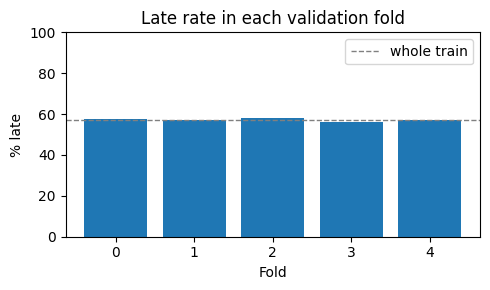

In [6]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(folds["fold"].astype(str), folds["val_late_%"])
ax.axhline(y.mean() * 100, color="grey", ls="--", lw=1, label="whole train")
ax.set_xlabel("Fold"); ax.set_ylabel("% late"); ax.set_ylim(0, 100); ax.set_title("Late rate in each validation fold"); ax.legend()
show(fig, "01_fold_late_rates")

### 2.3 Why grouping matters: plain vs grouped folds
The same KNN model scored with a **plain random KFold** and with the **grouped folds**. With the plain split, sibling items of the same
order (same features, same label) sit in training, so KNN copies their answer – the plain score looks better, but it is **leakage**.

In [7]:
knn_orders = pd.Series(groups.unique()).sample(frac=KNN_ORDER_FRAC, random_state=SEED)
k_mask = groups.isin(knn_orders).to_numpy()
Xk, yk, gk = X[k_mask].reset_index(drop=True), y[k_mask].reset_index(drop=True), groups[k_mask].reset_index(drop=True)
cv_k_grouped = make_cv(Xk, yk, gk)
cv_k_plain = list(KFold(n_splits=5, shuffle=True, random_state=SEED).split(Xk))
knn = build_full_pipeline(KNeighborsClassifier(n_neighbors=15, n_jobs=-1), PLAN, "standard")
plain_s, _ = cv_evaluate(knn, Xk, yk, cv_k_plain)
group_s, _ = cv_evaluate(knn, Xk, yk, cv_k_grouped)
pd.DataFrame({"plain KFold (leaky)": plain_s, "grouped (correct)": group_s}).loc[METRICS].round(4)

,plain KFold (leaky),grouped (correct)
roc_auc,0.8021,0.7442
accuracy,0.7193,0.6710
precision,0.7774,0.7275
recall,0.7046,0.6672
f1,0.7392,0.6960


## Step 3 – Outliers and skew
### 3.1 Numeric columns: skew and outliers
The model's numeric features, with the money columns (not model features) for comparison.

In [8]:
def iqr_share(s):
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean() * 100

context = [c for c in ["Sales", "Benefit per order", "Order Item Discount"] if c in X.columns]
cols = PLAN["numeric"] + context
skew_table = pd.DataFrame({"in_model": [c in PLAN["numeric"] for c in cols],
                           "skew": [X[c].skew() for c in cols], "outliers_%": [iqr_share(X[c]) for c in cols],
                           "min": [X[c].min() for c in cols], "max": [X[c].max() for c in cols]}, index=cols)
skew_table.round(2)

,in_model,skew,outliers_%,min,max
Order Item Quantity,True,0.88,0.00,1.00,5.00
order_weekday,True,-0.01,0.00,0.00,6.00
order_month,True,0.07,0.00,1.00,12.00
order_hour,True,0.00,0.00,0.00,23.00
order_quarter,True,0.08,0.00,1.00,4.00
is_weekend,True,0.94,0.00,0.00,1.00
Sales,False,2.92,0.27,9.99,1999.99
Benefit per order,False,-4.39,10.47,-3442.50,911.80
Order Item Discount,False,3.07,4.12,0.00,500.00


### 3.2 Distribution of the model's numeric features

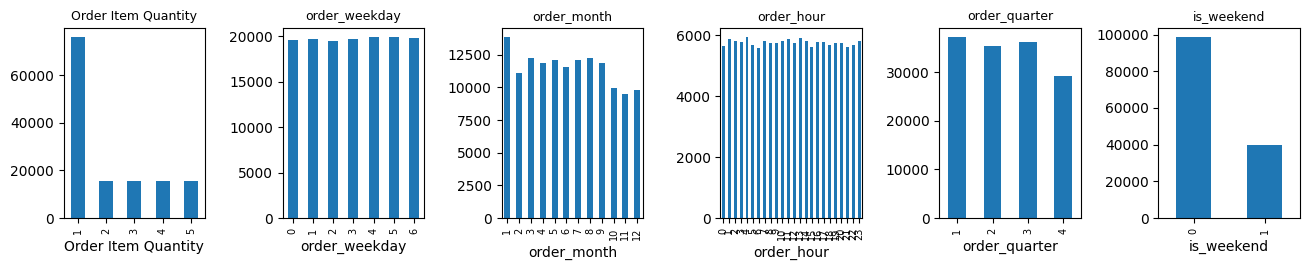

In [9]:
num = PLAN["numeric"]
fig, axes = plt.subplots(1, len(num), figsize=(2.2 * len(num), 2.8))
for ax, c in zip(np.atleast_1d(axes), num):
    X[c].value_counts().sort_index().plot.bar(ax=ax); ax.set_title(c, fontsize=9); ax.tick_params(axis="x", labelsize=7)
show(fig, "02_model_numeric_features")

### 3.3 Would clipping change the model's features?
If clipping at the 1st/99th percentile changes almost no rows and nothing is skewed, **no treatment is needed**.
Small-range counts (quantity 1–5, hour 0–23) can look skewed simply because some values are more common – that is not an outlier problem.

In [10]:
clip_effect = pd.Series({c: ((X[c] < X[c].quantile(0.01)) | (X[c] > X[c].quantile(0.99))).mean() * 100 for c in num},
                        name="rows_changed_by_clipping_%").round(2)
OUTLIER_DECISION = "none" if (clip_effect < 2).all() else "review"
print("Outlier treatment decision:", OUTLIER_DECISION)
clip_effect.to_frame()

Outlier treatment decision: none


,rows_changed_by_clipping_%
Order Item Quantity,0.0
order_weekday,0.0
order_month,0.0
order_hour,0.0
order_quarter,0.0
is_weekend,0.0


## Step 4 – Choose the scaling for each type of model
### 4.1 Cross-validated comparison (ROC-AUC, higher is better)
- **Logistic Regression** (linear): scaling gives fair, comparable coefficients.
- **KNN** (distance): distances depend directly on each column's range.
- **HistGB** (tree): splits on thresholds – scaling should not matter (checked once).

In [11]:
SCALER_OPTIONS = ["none", "standard", "robust", "minmax"]
rows = []
for sc in SCALER_OPTIONS:
    s, _ = cv_evaluate(build_full_pipeline(LogisticRegression(max_iter=1000), PLAN, sc), X, y, cv_splits)
    rows.append({"model": "Logistic", "scaler": sc, **s})
    s, _ = cv_evaluate(build_full_pipeline(KNeighborsClassifier(n_neighbors=15, n_jobs=-1), PLAN, sc), Xk, yk, cv_k_grouped)
    rows.append({"model": "KNN (30% orders)", "scaler": sc, **s})
for sc in ["none", "standard"]:
    s, _ = cv_evaluate(build_full_pipeline(HistGradientBoostingClassifier(max_iter=200, random_state=SEED), PLAN, sc), X, y, cv_splits)
    rows.append({"model": "HistGB (tree)", "scaler": sc, **s})
scale_results = pd.DataFrame(rows)
scale_results.round(4)

,model,scaler,roc_auc,accuracy,precision,recall,f1,roc_auc_std
0,Logistic,none,0.7449,0.7146,0.8857,0.5751,0.6974,0.0039
1,KNN (30% orders),none,0.6734,0.6301,0.6836,0.6420,0.6621,0.0033
2,Logistic,standard,0.7450,0.7141,0.8848,0.5750,0.6970,0.0038
3,KNN (30% orders),standard,0.7442,0.6710,0.7275,0.6672,0.6960,0.0038
4,Logistic,robust,0.7449,0.7143,0.8849,0.5753,0.6972,0.0038
5,KNN (30% orders),robust,0.7396,0.6741,0.7323,0.6662,0.6977,0.0036
6,Logistic,minmax,0.7449,0.7146,0.8858,0.5751,0.6974,0.0038
7,KNN (30% orders),minmax,0.7419,0.6719,0.7275,0.6698,0.6974,0.0046
8,HistGB (tree),none,0.7720,0.7173,0.8635,0.6006,0.7084,0.0044
9,HistGB (tree),standard,0.7720,0.7173,0.8635,0.6006,0.7084,0.0044


### 4.2 Comparison chart

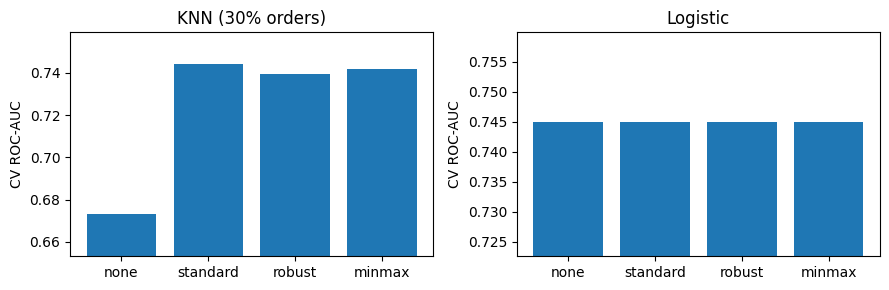

In [12]:
pivot = scale_results[scale_results["model"] != "HistGB (tree)"].pivot(index="scaler", columns="model", values="roc_auc").loc[SCALER_OPTIONS]
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, m in zip(axes, pivot.columns):
    ax.bar(pivot.index, pivot[m]); ax.set_title(m); ax.set_ylabel("CV ROC-AUC")
    ax.set_ylim(pivot[m].min() * 0.97, pivot[m].max() * 1.02)
show(fig, "03_scaling_comparison")

### 4.3 Decision per model family
Highest ROC-AUC wins; differences smaller than `roc_auc_std` are not meaningful (prefer the simpler option).

In [13]:
def best_scaler(model):
    r = scale_results[scale_results["model"] == model].sort_values("roc_auc", ascending=False).iloc[0]
    return {"scaler": r["scaler"], "cv_roc_auc": round(float(r["roc_auc"]), 4)}

tree = scale_results[scale_results["model"] == "HistGB (tree)"].set_index("scaler")["roc_auc"]
CHOICE = {"linear (Logistic Regression)": best_scaler("Logistic"),
          "distance (KNN)": best_scaler("KNN (30% orders)"),
          "tree (Decision Tree / Random Forest / XGBoost)": {"scaler": "none", "cv_roc_auc": round(float(tree["none"]), 4)}}
print(f"HistGB ROC-AUC without scaling {tree['none']:.4f} vs with scaling {tree['standard']:.4f}")
pd.DataFrame(CHOICE).T

HistGB ROC-AUC without scaling 0.7720 vs with scaling 0.7720


,scaler,cv_roc_auc
linear (Logistic Regression),standard,0.745
distance (KNN),standard,0.7442
tree (Decision Tree / Random Forest / XGBoost),none,0.772


## Step 5 – Scores in use: baselines and the team's features
### 5.1 All scores

In [14]:
mode_plan = {"numeric": [], "onehot": ["Shipping Mode"], "onehot_rare": [], "target": []}
candidates = {
    "Baseline: always 'late'": build_full_pipeline(DummyClassifier(strategy="constant", constant=1), PLAN),
    "Baseline: Shipping Mode only": build_full_pipeline(LogisticRegression(max_iter=1000), mode_plan, "standard"),
    "Team features: Logistic": build_full_pipeline(LogisticRegression(max_iter=1000), PLAN, CHOICE["linear (Logistic Regression)"]["scaler"]),
    "Team features: HistGB (default)": build_full_pipeline(HistGradientBoostingClassifier(max_iter=200, random_state=SEED), PLAN),
}
res_rows, per_fold_all, oof = [], {}, {}
for name, pipe in candidates.items():
    summary, per_fold, oof[name] = cv_evaluate(pipe, X, y, cv_splits, return_proba=True)
    per_fold_all[name] = per_fold
    res_rows.append({"model": name, **summary})
metric_table = pd.DataFrame(res_rows).set_index("model")
metric_table.round(4)

,roc_auc,accuracy,precision,recall,f1,roc_auc_std
model,,,,,,
Baseline: always 'late',0.5000,0.5718,0.5718,1.0000,0.7275,0.0000
Baseline: Shipping Mode only,0.7414,0.6968,0.8868,0.5385,0.6701,0.0035
Team features: Logistic,0.7450,0.7141,0.8848,0.5750,0.6970,0.0038
Team features: HistGB (default),0.7720,0.7173,0.8635,0.6006,0.7084,0.0044


### 5.2 Per-fold scores (stability)

In [15]:
per_fold_all["Team features: HistGB (default)"].round(4)

,fold,roc_auc,accuracy,precision,recall,f1
0,0,0.7690,0.7083,0.8574,0.5926,0.7008
1,1,0.7776,0.7219,0.8685,0.6045,0.7128
2,2,0.7686,0.7140,0.8656,0.5993,0.7083
3,3,0.7758,0.7230,0.8585,0.6053,0.7100
4,4,0.7688,0.7194,0.8675,0.6012,0.7102


### 5.3 Predicted late-probability for late vs on-time orders
A good model gives **higher** probabilities to orders that really were late. The more the two histograms are separated, the higher the ROC-AUC.

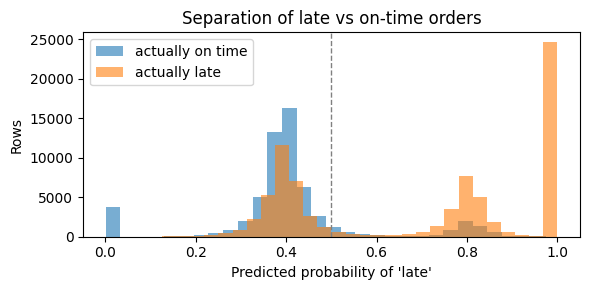

In [16]:
p = oof["Team features: HistGB (default)"]
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(p[y.to_numpy() == 0], bins=30, alpha=0.6, label="actually on time")
ax.hist(p[y.to_numpy() == 1], bins=30, alpha=0.6, label="actually late")
ax.axvline(0.5, color="grey", ls="--", lw=1)
ax.set_xlabel("Predicted probability of 'late'"); ax.set_ylabel("Rows"); ax.set_title("Separation of late vs on-time orders"); ax.legend()
show(fig, "04_probability_separation")

## Step 6 – Save the decision and log the experiments

In [17]:
decision = {"task": "classification", "target": TARGET, "features": FEATURES,
            "validation": "StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42), grouped by Order Id, stratified on the label",
            "metrics": METRICS, "primary_metric": "roc_auc", "business_priority": "recall",
            "outlier_treatment": OUTLIER_DECISION, "scaler_by_model_family": CHOICE,
            "reference_cv_roc_auc": metric_table["roc_auc"].round(4).to_dict()}
(RESULTS_DIR / "clf_m4_preprocessing.json").write_text(json.dumps(decision, indent=2), encoding="utf-8")
for _, r in scale_results.iterrows():
    log_experiment({"owner": "M4", "experiment": f"scaler_{r['scaler']}", "model": r["model"], "n_features": len(FEATURES),
                    **{m: r[m] for m in METRICS}, "roc_auc_std": r["roc_auc_std"]})
for name, r in metric_table.iterrows():
    log_experiment({"owner": "M4", "experiment": "reference", "model": name, "n_features": len(FEATURES),
                    **{m: r[m] for m in METRICS}, "roc_auc_std": r["roc_auc_std"]})
print("Saved clf_m4_preprocessing.json")

Saved clf_m4_preprocessing.json


## Step 7 – Final check on the test set (transform only)
Nothing is fitted on the test set; this only proves the preprocessing runs for every model family.

In [18]:
test = pd.read_csv(PROCESSED_DIR / "test_clf_fe.csv")
if CATEGORY_COL == "Category Id":
    test[CATEGORY_COL] = test[CATEGORY_COL].astype(str)
X_te = test.drop(columns=[TARGET])
checks = {}
for family, opt in CHOICE.items():
    prep = build_full_pipeline(DummyClassifier(), PLAN, opt["scaler"])[:-1].fit(X, y)
    Xt_te = prep.transform(X_te)
    checks[family] = {"scaler": opt["scaler"], "test_matrix": Xt_te.shape, "missing": bool(np.isnan(Xt_te).any())}
pd.DataFrame(checks).T

,scaler,test_matrix,missing
linear (Logistic Regression),standard,"(34534, 20)",False
distance (KNN),standard,"(34534, 20)",False
tree (Decision Tree / Random Forest / XGBoost),none,"(34534, 20)",False


## Step 8 – Viva summary

In [19]:
print(f'''
VALIDATION   5-fold StratifiedGroupKFold by Order Id | shared orders: {int(folds["orders_in_both"].sum())}
FOLD BALANCE val late % {folds["val_late_%"].min():.1f}-{folds["val_late_%"].max():.1f} (whole train {y.mean() * 100:.1f}%)
GROUPING     KNN plain KFold ROC-AUC {plain_s["roc_auc"]:.4f} vs grouped {group_s["roc_auc"]:.4f}
OUTLIERS     model features need treatment: {OUTLIER_DECISION}
SCALING      linear: {CHOICE["linear (Logistic Regression)"]["scaler"]} | KNN: {CHOICE["distance (KNN)"]["scaler"]} | trees: none
BASELINES    always late ROC-AUC {metric_table.loc["Baseline: always 'late'", "roc_auc"]:.3f} | Shipping Mode {metric_table.loc["Baseline: Shipping Mode only", "roc_auc"]:.3f}
TEAM (untuned) Logistic {metric_table.loc["Team features: Logistic", "roc_auc"]:.3f} | HistGB {metric_table.loc["Team features: HistGB (default)", "roc_auc"]:.3f} ROC-AUC
''')


VALIDATION   5-fold StratifiedGroupKFold by Order Id | shared orders: 0
FOLD BALANCE val late % 56.0-57.9 (whole train 57.2%)
GROUPING     KNN plain KFold ROC-AUC 0.8021 vs grouped 0.7442
OUTLIERS     model features need treatment: none
SCALING      linear: standard | KNN: standard | trees: none
BASELINES    always late ROC-AUC 0.500 | Shipping Mode 0.741
TEAM (untuned) Logistic 0.745 | HistGB 0.772 ROC-AUC



**My contribution in one sentence:** I designed and verified the grouped, stratified cross-validation, checked outliers, chose the scaling for
each type of model, and defined the scores the whole team evaluates with.